# 🏨 RevPAR Collapse Under Geopolitical Stress
## Hotel Losses by Chain & Big Hotels: Iran–US Conflict

This notebook analyzes the financial and operational impact of the Iran–US conflict 
on the Middle East hospitality sector, across 36 landmark hotels, multiple chains, 
and 10 countries, tracing how geopolitical escalation translates into measurable 
revenue loss, occupancy collapse, and long-term recovery uncertainty.

**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn  
**Author:** Nour Elhouda — Elhouda Lab

# 1. Data Loading


### 1.1 Importing Libraries


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### 1.2 Loading Datasets

Loading all six datasets and verifying shape and data quality.

In [7]:

path = os.path.join(os.getcwd(), "Hotel_losses", "datasets")

big = pd.read_csv(os.path.join(path, "big_hotels_impact.csv"))
cancel = pd.read_csv(os.path.join(path, "booking_cancellations.csv"))
timeline = pd.read_csv(os.path.join(path, "conflict_timeline_hotel.csv"))
country = pd.read_csv(os.path.join(path, "country_tourism_impact.csv"))
chain = pd.read_csv(os.path.join(path, "hotel_chain_performance.csv"))
recovery = pd.read_csv(os.path.join(path, "recovery_forecast.csv"))

for name, df in [("big_hotels_impact", big), ("booking_cancellations", cancel),
                 ("conflict_timeline_hotel", timeline), ("country_tourism_impact", country),
                 ("hotel_chain_performance", chain), ("recovery_forecast", recovery)]:
    print(f"{name}: {df.shape}")

big_hotels_impact: (180, 20)
booking_cancellations: (600, 19)
conflict_timeline_hotel: (22, 9)
country_tourism_impact: (100, 16)
hotel_chain_performance: (3390, 17)
recovery_forecast: (840, 11)


In [8]:
print("=== DATA QUALITY CHECK ===")
for name, df in [("big_hotels_impact", big), ("booking_cancellations", cancel),
                 ("conflict_timeline_hotel", timeline), ("country_tourism_impact", country),
                 ("hotel_chain_performance", chain), ("recovery_forecast", recovery)]:
    nulls = df.isnull().sum().sum()
    print(f"{name}: {df.shape} | nulls: {nulls}")

=== DATA QUALITY CHECK ===
big_hotels_impact: (180, 20) | nulls: 0
booking_cancellations: (600, 19) | nulls: 0
conflict_timeline_hotel: (22, 9) | nulls: 0
country_tourism_impact: (100, 16) | nulls: 0
hotel_chain_performance: (3390, 17) | nulls: 0
recovery_forecast: (840, 11) | nulls: 0


### 1.3 Data Quality Check

Inspecting column names, data types, and null values for each dataset.

In [12]:
datasets = {
    "big_hotels_impact": big,
    "booking_cancellations": cancel,
    "conflict_timeline_hotel": timeline,
    "country_tourism_impact": country,
    "hotel_chain_performance": chain,
    "recovery_forecast": recovery
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(f"Shape: {df.shape}")
    print(df.dtypes)
    print(f"Nulls: {df.isnull().sum().sum()}")


TABLE: big_hotels_impact
Shape: (180, 20)
hotel_name                   str
hotel_chain                  str
city                         str
country                      str
hotel_tier                   str
conflict_phase               str
phase_start                  str
phase_end                    str
total_rooms                int64
occupancy_rate_pct       float64
adr_usd                  float64
revpar_usd               float64
actual_revenue_usd       float64
expected_revenue_usd     float64
revenue_loss_usd         float64
revenue_loss_pct         float64
cancellation_rate_pct    float64
intl_guests_pct          float64
staff_impact_pct         float64
country_risk_level           str
dtype: object
Nulls: 0

TABLE: booking_cancellations
Shape: (600, 19)
cancellation_id              str
cancellation_date            str
original_checkin_date        str
lead_time_days             int64
conflict_phase               str
hotel_chain                  str
hotel_tier                   

### 1.4 Sample Preview

Previewing the first few rows of each dataset.

In [13]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    display(df.head(3))


TABLE: big_hotels_impact


,hotel_name,hotel_chain,city,country,hotel_tier,conflict_phase,phase_start,phase_end,total_rooms,occupancy_rate_pct,adr_usd,revpar_usd,actual_revenue_usd,expected_revenue_usd,revenue_loss_usd,revenue_loss_pct,cancellation_rate_pct,intl_guests_pct,staff_impact_pct,country_risk_level
0,Burj Al Arab,Jumeirah Group,Dubai,UAE,Ultra-Luxury,Pre-Tension,2024-01-01,2024-12-31,202,79.54,1896.36,1508.41,111214900.0,101197940.0,0.0,0.00,0.00,30.6,0.00,High
1,Burj Al Arab,Jumeirah Group,Dubai,UAE,Ultra-Luxury,Escalation,2025-01-01,2025-05-31,202,62.32,1821.37,1135.11,34393801.0,41588194.0,7194393.0,17.30,17.10,16.6,7.78,High
2,Burj Al Arab,Jumeirah Group,Dubai,UAE,Ultra-Luxury,Active Conflict,2025-06-01,2025-12-31,202,52.33,1787.84,935.49,40250410.0,59055236.0,18804826.0,31.84,23.86,38.7,14.33,High



TABLE: booking_cancellations


,cancellation_id,cancellation_date,original_checkin_date,lead_time_days,conflict_phase,hotel_chain,hotel_tier,country,city,guest_nationality,booking_type,nights_booked,guests,room_type,adr_usd,revenue_lost_usd,cancellation_reason,refund_issued,channel
0,CXL-0001,2025-12-01,2025-12-31,30,Active Conflict,Hyatt Hotels,Luxury/Upper-Upscale,Qatar,Al Rayyan,Chinese,Business,5,2,Suite,1735.69,8678.45,Insurance non-coverage,Full Refund,OTA
1,CXL-0002,2026-03-08,2026-03-27,19,Peak Crisis,Anantara Hotels,Luxury,Kuwait,Kuwait City,Chinese,Leisure,2,4,Suite,446.59,893.18,Safety concerns — conflict proximity,Full Refund,GDS
2,CXL-0003,2026-04-30,2026-05-21,21,Post-Ceasefire,IHG Hotels & Resorts,Upper-Upscale,Bahrain,Manama,Chinese,Group,12,1,Standard,999.81,11997.70,Corporate travel ban,Partial Refund,GDS



TABLE: conflict_timeline_hotel


...

,quarter,quarter_start,quarter_end,conflict_phase,country,risk_level,intl_tourist_arrivals,arrivals_yoy_change_pct,hotel_revenue_usd_m,expected_revenue_usd_m,hotel_revenue_loss_usd_m,revenue_loss_pct,avg_hotel_occupancy_pct,gdp_impact_usd_bn,jobs_at_risk,travel_advisory_level
0,2024-Q1,2024-01-01,2024-03-31,Pre-Tension,UAE,High,5174144,4.8,2947.1,3125.0,177.9,5.69,71.9,1.194,7790,Level 1 - Normal
1,2024-Q1,2024-01-01,2024-03-31,Pre-Tension,Saudi Arabia,High,3750140,6.7,1798.0,1800.0,2.0,0.11,74.1,0.011,58,Level 1 - Normal
2,2024-Q1,2024-01-01,2024-03-31,Pre-Tension,Qatar,High,1076239,0.9,1187.5,1275.0,87.5,6.87,84.5,0.545,3796,Level 1 - Normal



TABLE: hotel_chain_performance


,month,conflict_phase,hotel_chain,chain_hq_country,chain_tier,country,risk_level,total_rooms,occupancy_rate_pct,adr_usd,revpar_usd,total_revenue_usd,expected_revenue_usd,revenue_loss_usd,revenue_loss_pct,booking_cancellations,avg_length_of_stay_nights
0,2024-01,Pre-Tension,Marriott International,USA,Luxury/Upper-Upscale,UAE,High,607,62.39,255.38,159.33,2901482.0,3214501.0,313019.0,9.74,2311,2.43
1,2024-02,Pre-Tension,Marriott International,USA,Luxury/Upper-Upscale,UAE,High,607,64.74,278.90,180.57,3288229.0,3214501.0,0.0,0.00,2640,4.98
2,2024-03,Pre-Tension,Marriott International,USA,Luxury/Upper-Upscale,UAE,High,607,65.54,296.61,194.41,3540120.0,3214501.0,0.0,0.00,2138,3.02



TABLE: recovery_forecast


,recovery_period,scenario,country,risk_level,hotel_tier,recovery_rate_vs_2024,projected_occupancy_pct,projected_revpar_index,investor_confidence_idx,new_hotel_openings_expected,intl_airline_routes_restored_pct
0,2026Q3,Optimistic,UAE,High,Upper-Upscale,53.0,45.1,53.0,24.8,2,48.7
1,2026Q4,Optimistic,UAE,High,Upper-Upscale,62.9,53.5,62.9,41.2,4,57.8
2,2027H1,Optimistic,UAE,High,Upper-Upscale,69.6,59.2,69.6,61.9,3,59.0


# 2. Exploratory Data Analysis (EDA)

### 2.1 Revenue Loss by Conflict Phase

Examining how average revenue loss escalated across the five conflict phases.

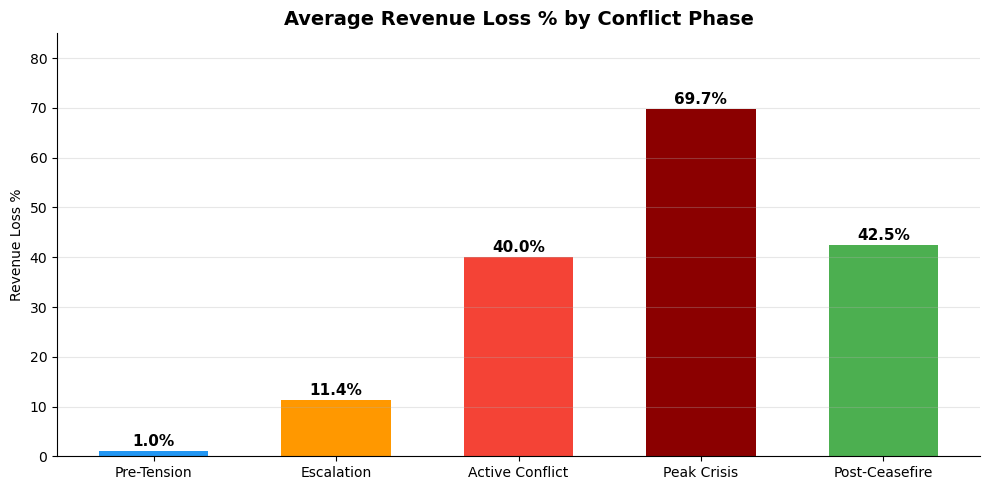

In [15]:
PHASE_ORDER = big[['conflict_phase', 'phase_start']].drop_duplicates().sort_values('phase_start')['conflict_phase'].tolist()
PHASE_COLORS = ['#2196F3', '#FF9800', '#F44336', '#8B0000', '#4CAF50']

phase_data = big.groupby('conflict_phase')['revenue_loss_pct'].mean().reindex(PHASE_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(PHASE_ORDER, phase_data.values, color=PHASE_COLORS, width=0.6)

for bar, val in zip(bars, phase_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Average Revenue Loss % by Conflict Phase', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue Loss %')
ax.set_ylim(0, 85)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 2.2 Top Hotels by Total Revenue Loss

Identifying which individual properties absorbed the greatest financial impact.

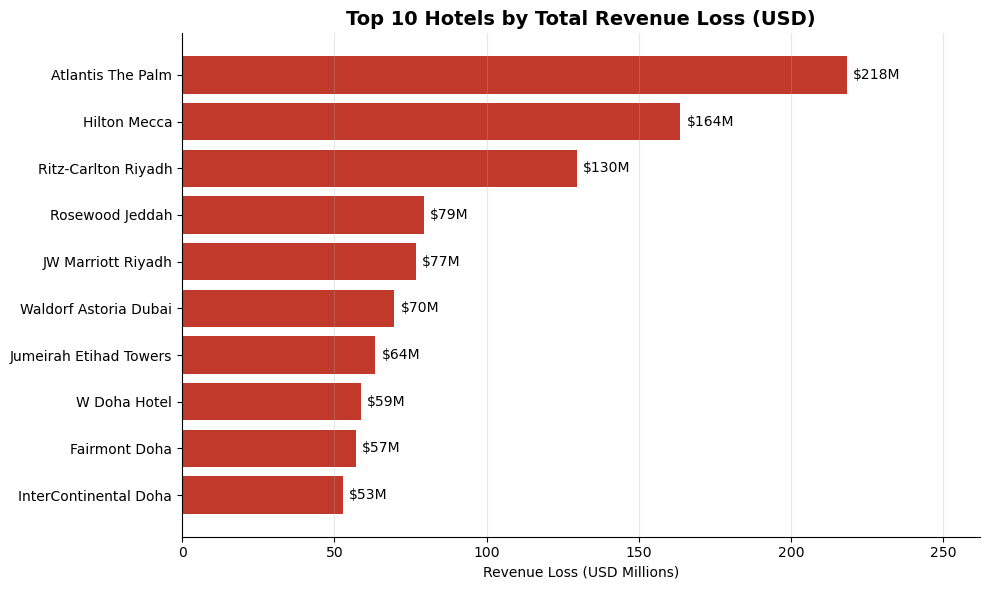

In [16]:
hotel_loss = big.groupby('hotel_name')['revenue_loss_usd'].sum().sort_values(ascending=True).tail(10) / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(hotel_loss.index, hotel_loss.values, color='#c0392b')

for bar, val in zip(bars, hotel_loss.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}M', va='center', fontsize=10)

ax.set_title('Top 10 Hotels by Total Revenue Loss (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Loss (USD Millions)')
ax.set_xlim(0, hotel_loss.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 2.3 Revenue Loss by Hotel Tier

Comparing total financial impact across hotel tiers to understand which segment absorbed the most loss.

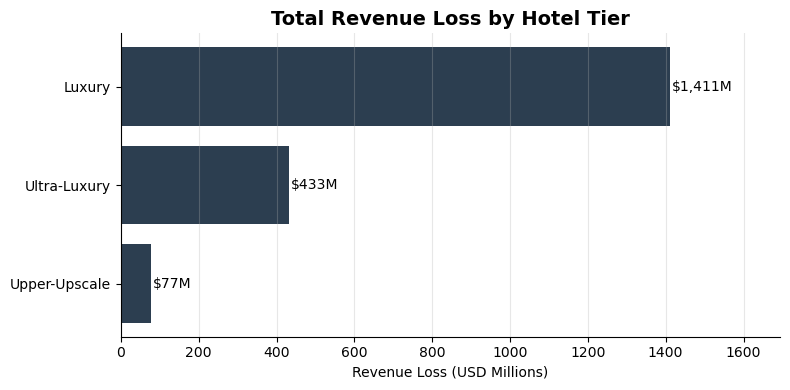

In [17]:
tier_loss = big.groupby('hotel_tier')['revenue_loss_usd'].sum().sort_values(ascending=True) / 1e6

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(tier_loss.index, tier_loss.values, color='#2c3e50')

for bar, val in zip(bars, tier_loss.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}M', va='center', fontsize=10)

ax.set_title('Total Revenue Loss by Hotel Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Loss (USD Millions)')
ax.set_xlim(0, tier_loss.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 2.4 Country-Level Revenue Loss

Examining which countries absorbed the greatest hotel revenue losses across the conflict period.

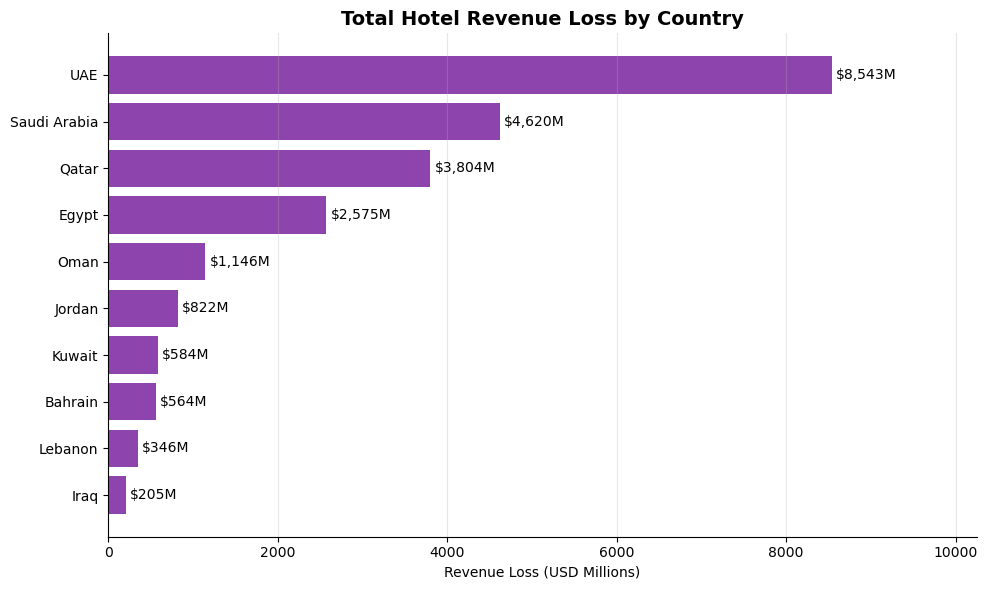

In [18]:
country_loss = country.groupby('country')['hotel_revenue_loss_usd_m'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_loss.index, country_loss.values, color='#8e44ad')

for bar, val in zip(bars, country_loss.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}M', va='center', fontsize=10)

ax.set_title('Total Hotel Revenue Loss by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Loss (USD Millions)')
ax.set_xlim(0, country_loss.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 2.5 Cancellation Analysis

Examining why bookings were cancelled and which conflict phases drove the most cancellation revenue loss.

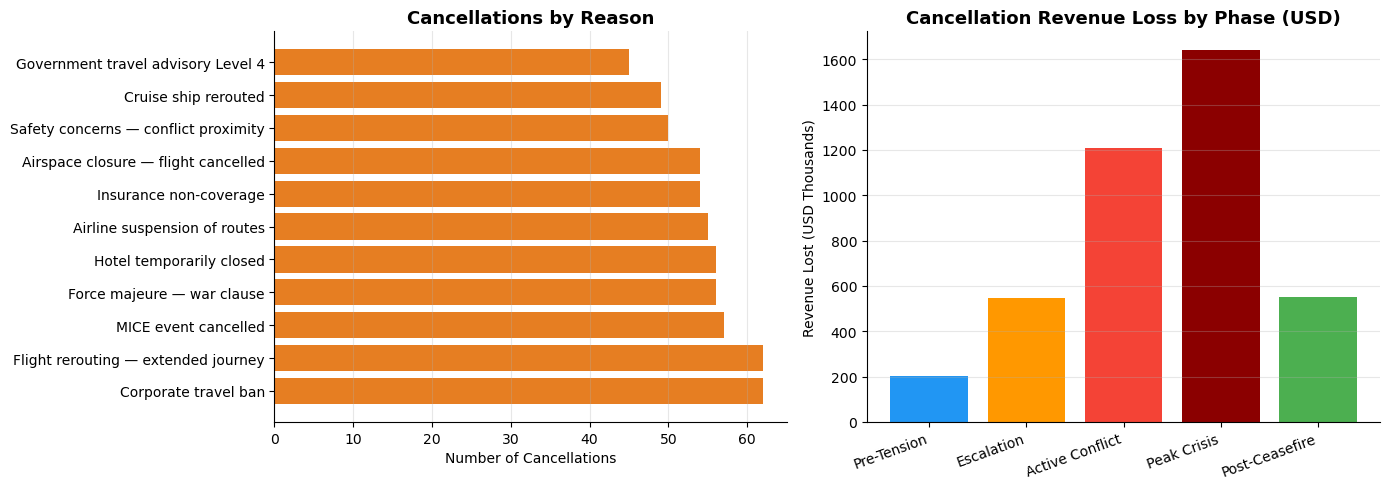

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cancellation reasons
reasons = cancel['cancellation_reason'].value_counts()
axes[0].barh(reasons.index, reasons.values, color='#e67e22')
axes[0].set_title('Cancellations by Reason', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cancellations')
axes[0].grid(axis='x', alpha=0.3)

# Revenue lost by conflict phase
phase_cancel = cancel.groupby('conflict_phase')['revenue_lost_usd'].sum().reindex(PHASE_ORDER) / 1e3
axes[1].bar(PHASE_ORDER, phase_cancel.values, color=PHASE_COLORS)
axes[1].set_title('Cancellation Revenue Loss by Phase (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue Lost (USD Thousands)')
axes[1].set_xticklabels(PHASE_ORDER, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### 2.6 Hotel Chain Performance

Comparing total revenue loss across hotel chains operating in the region.

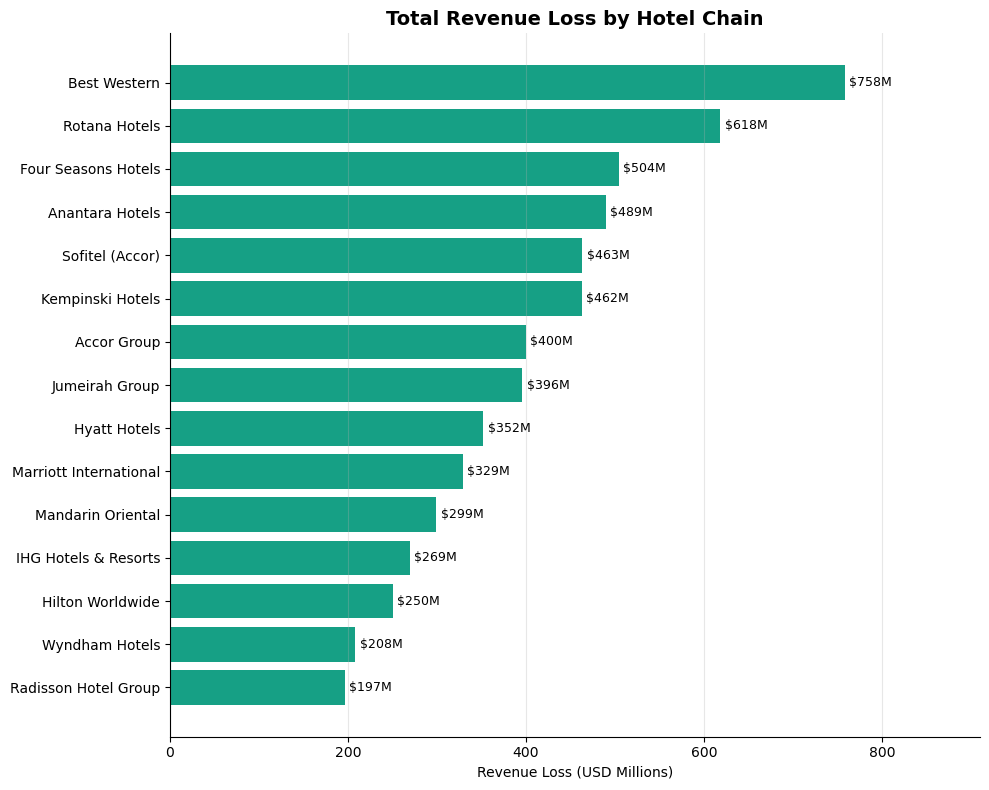

In [20]:
chain_loss = chain.groupby('hotel_chain')['revenue_loss_usd'].sum().sort_values(ascending=True) / 1e6

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(chain_loss.index, chain_loss.values, color='#16a085')

for bar, val in zip(bars, chain_loss.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}M', va='center', fontsize=9)

ax.set_title('Total Revenue Loss by Hotel Chain', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Loss (USD Millions)')
ax.set_xlim(0, chain_loss.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# 3. Statistical Analysis



### 3.1 Correlation Analysis

Examining relationships between key numerical variables to understand what drives revenue loss.

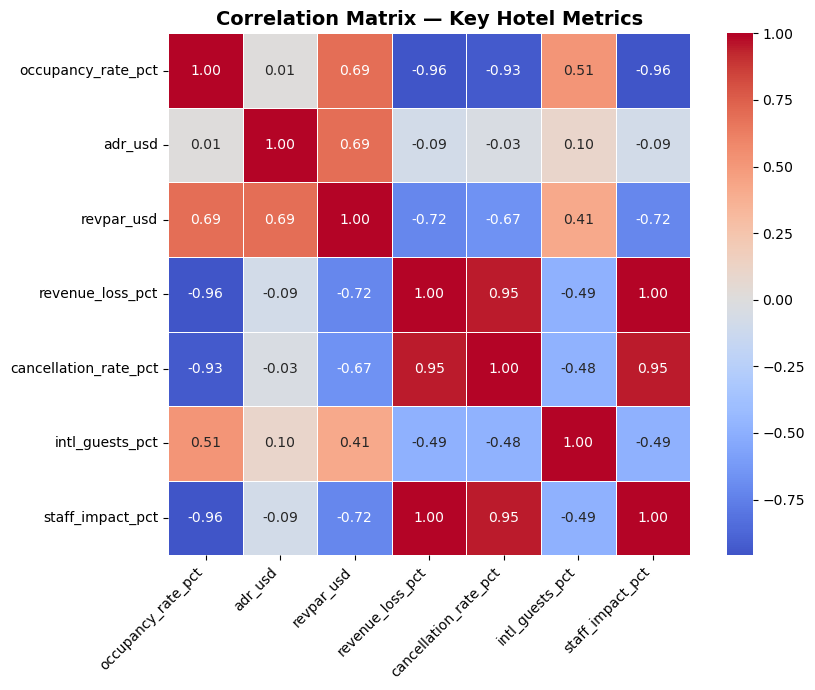

In [25]:
cols = ['occupancy_rate_pct', 'adr_usd', 'revpar_usd', 'revenue_loss_pct', 
        'cancellation_rate_pct', 'intl_guests_pct', 'staff_impact_pct']

corr = big[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Hotel Metrics', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Regression — What Drives Revenue Loss?

Fitting a linear regression to quantify the individual contribution of occupancy rate, cancellation rate, and international guest share to revenue loss percentage.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

features = ['occupancy_rate_pct', 'cancellation_rate_pct', 'intl_guests_pct', 'adr_usd']
target = 'revenue_loss_pct'

X = big[features]
y = big[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")
print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.4f}")

R² Score: 0.9482

Feature Coefficients:
  occupancy_rate_pct: -14.6531
  cancellation_rate_pct: 10.5671
  intl_guests_pct: 0.4764
  adr_usd: -1.6722


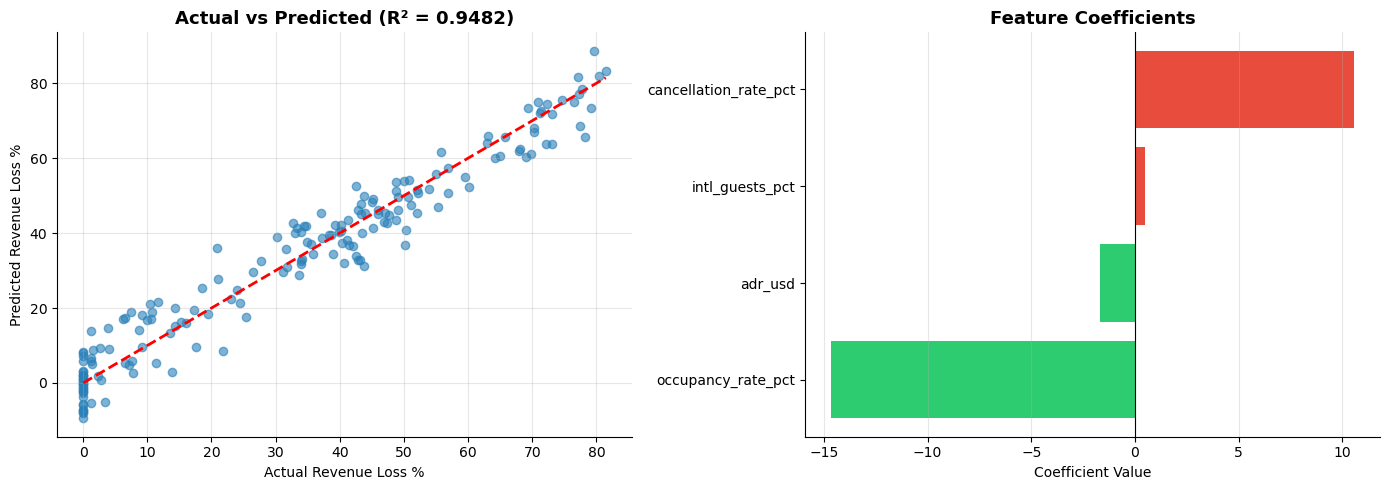

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y, y_pred, alpha=0.6, color='#2980b9')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Revenue Loss %')
axes[0].set_ylabel('Predicted Revenue Loss %')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Feature importance
coef_df = pd.Series(model.coef_, index=features).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df.values]
axes[1].barh(coef_df.index, coef_df.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].grid(axis='x', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

# 4. Recovery Forecast

### 4.1 Scenario Comparison

Projecting recovery trajectories across Optimistic, Base Case, and Pessimistic scenarios for the top 4 most impacted countries.

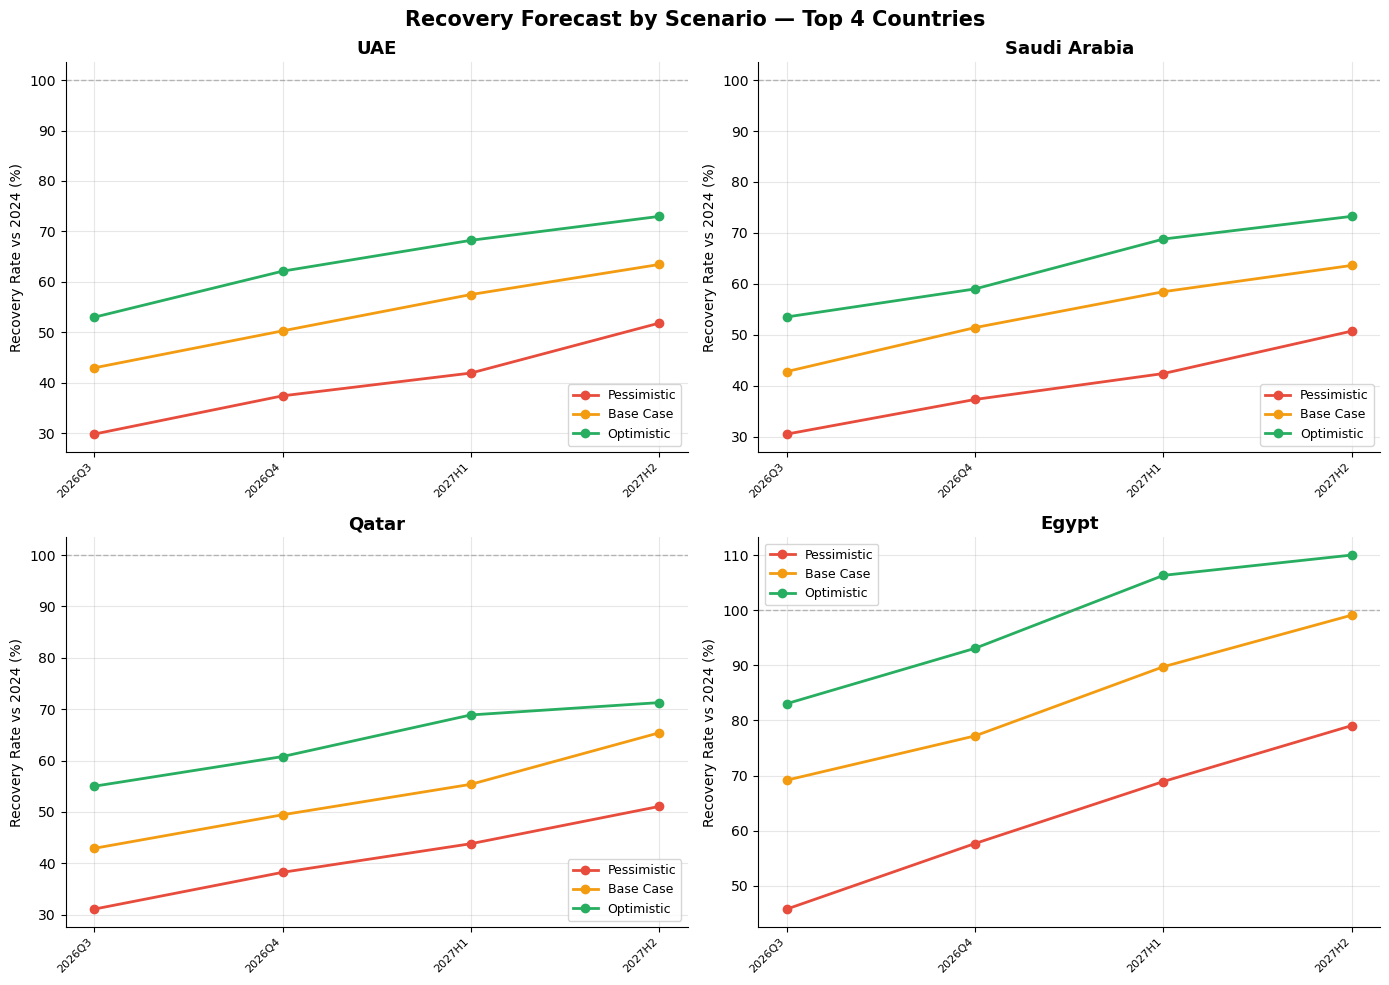

In [28]:
top_countries = ['UAE', 'Saudi Arabia', 'Qatar', 'Egypt']
scenarios = ['Pessimistic', 'Base Case', 'Optimistic']
scen_colors = ['#e74c3c', '#f39c12', '#27ae60']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, c in enumerate(top_countries):
    df_c = recovery[recovery['country'] == c]
    periods = df_c['recovery_period'].unique()
    
    for scen, col in zip(scenarios, scen_colors):
        df_s = df_c[df_c['scenario'] == scen].groupby('recovery_period')['recovery_rate_vs_2024'].mean()
        df_s = df_s.reindex(periods)
        axes[i].plot(range(len(periods)), df_s.values, marker='o', label=scen, color=col, linewidth=2)
    
    axes[i].axhline(100, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].set_title(f'{c}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Recovery Rate vs 2024 (%)')
    axes[i].set_xticks(range(len(periods)))
    axes[i].set_xticklabels(periods, rotation=45, ha='right', fontsize=8)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Recovery Forecast by Scenario — Top 4 Countries', fontsize=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

# 5. Key Findings 


Summarizing the most important analytical insights from this project.

## 5. Key Findings

Summarizing the most important analytical insights from this project.

1. **Peak Crisis was the most destructive phase** — average revenue loss reached 69.7%, nearly double Active Conflict (40%). Damage persisted into Post-Ceasefire at 42.5%, confirming that recovery does not begin when fighting stops.

2. **Atlantis The Palm absorbed the single largest loss** at $218M, followed by Hilton Mecca ($164M) and Ritz-Carlton Riyadh ($130M).

3. **Luxury tier lost $1.41B in total** — more than 3x Ultra-Luxury ($433M), driven by higher property volume rather than per-property exposure.

4. **UAE suffered the greatest country-level loss at $8.54B** — nearly double Saudi Arabia ($4.62B), reflecting Dubai's structural dependence on international tourism.

5. **Corporate travel bans and flight rerouting were the dominant cancellation drivers** — institutional decisions, not individual fear, cut off demand.

6. **Occupancy rate is the primary predictor of revenue loss** (coefficient: -14.65). A linear regression on four variables explained 94.8% of revenue loss variance (R² = 0.9482).

7. **Egypt is the only market projected to fully recover** by 2027H2 under the Optimistic scenario. UAE, Saudi Arabia, and Qatar remain below 2024 baseline across all scenarios.